# Soil Quality Analysis - Data Visualization
## Haryana Soil Health: 2016-2017 vs 2025 Comparison

This notebook contains comprehensive visualizations for soil quality analysis.

## 1. Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load processed data
df = pd.read_excel('soil_quality_analysis_results.xlsx')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns with scores: {len([col for col in df.columns if '_scale(1-10)' in col])}")

Dataset loaded: 3850 rows, 82 columns

Columns with scores: 24


## 2. Soil Health Distribution (2016-2017 vs 2025)

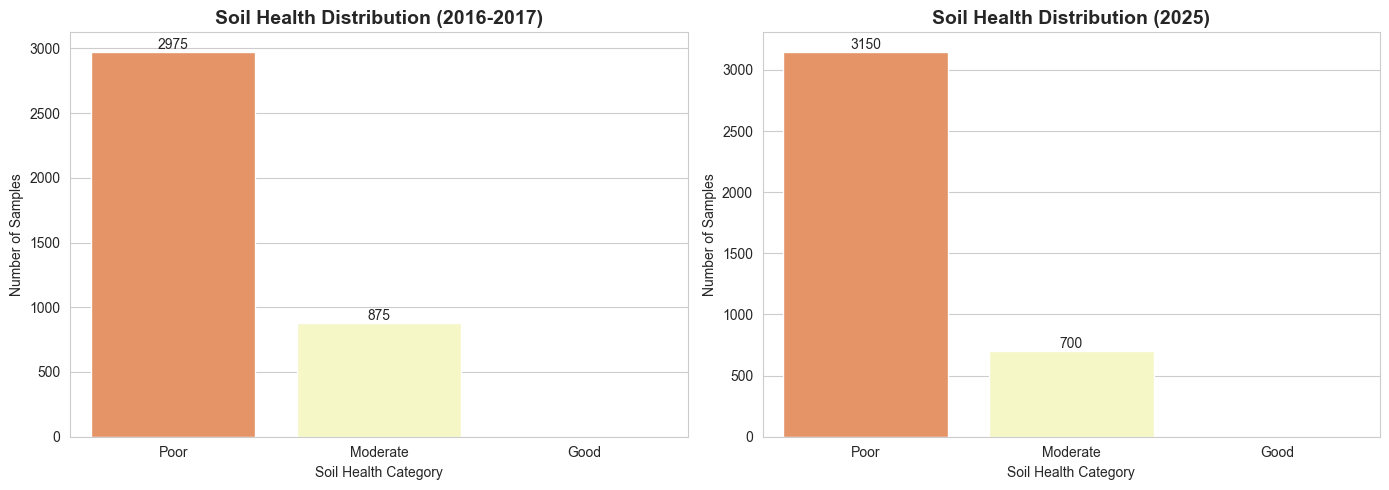


2016-2017 Distribution:
Soil_Health
Poor        2975
Moderate     875
Name: count, dtype: int64

2025 Distribution:
Soil_Health_2025
Poor        3150
Moderate     700
Name: count, dtype: int64


In [3]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2016-2017 Distribution
sns.countplot(x='Soil_Health', data=df, order=['Poor', 'Moderate', 'Good'], 
              palette='RdYlGn', ax=axes[0])
axes[0].set_title('Soil Health Distribution (2016-2017)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Soil Health Category')

# Add percentage labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 2025 Distribution
sns.countplot(x='Soil_Health_2025', data=df, order=['Poor', 'Moderate', 'Good'], 
              palette='RdYlGn', ax=axes[1])
axes[1].set_title('Soil Health Distribution (2025)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xlabel('Soil Health Category')

# Add percentage labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout()
plt.savefig('01_soil_health_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\n2016-2017 Distribution:")
print(df['Soil_Health'].value_counts())
print("\n2025 Distribution:")
print(df['Soil_Health_2025'].value_counts())

## 3. Soil Health Comparison Matrix (2016-2017 vs 2025)

<Figure size 1000x600 with 0 Axes>

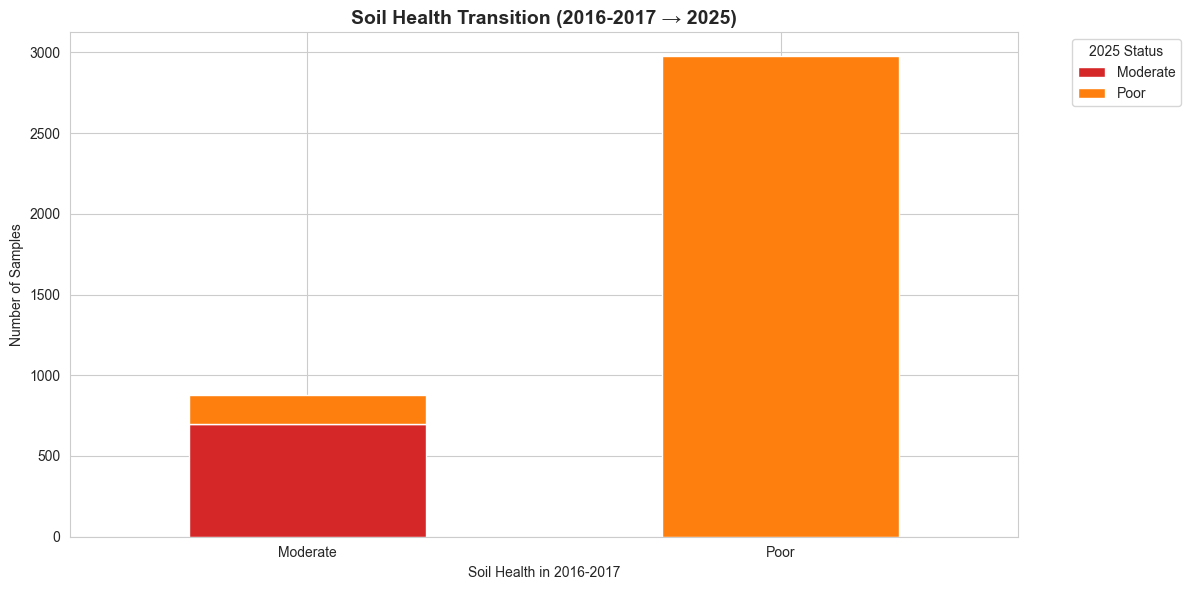


Transition Matrix:
2025       Moderate  Poor
2016-2017                
Moderate        700   175
Poor              0  2975

Key Insights:
- Samples that degraded (Moderate → Poor): 175
- Samples that remained Poor: 2975
- Samples that remained Moderate: 700


In [4]:
# Create comparison crosstab
comparison = pd.crosstab(df['Soil_Health'], df['Soil_Health_2025'], 
                         rownames=['2016-2017'], colnames=['2025'])

# Stacked bar chart
plt.figure(figsize=(10, 6))
comparison.plot(kind='bar', stacked=True, color=['#d62728', '#ff7f0e', '#2ca02c'])
plt.title('Soil Health Transition (2016-2017 → 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Soil Health in 2016-2017')
plt.ylabel('Number of Samples')
plt.legend(title='2025 Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('02_soil_health_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTransition Matrix:")
print(comparison)
print("\nKey Insights:")
print(f"- Samples that degraded (Moderate → Poor): {comparison.loc['Moderate', 'Poor']}")
print(f"- Samples that remained Poor: {comparison.loc['Poor', 'Poor']}")
print(f"- Samples that remained Moderate: {comparison.loc['Moderate', 'Moderate']}")

## 4. Nutrient Distribution Analysis

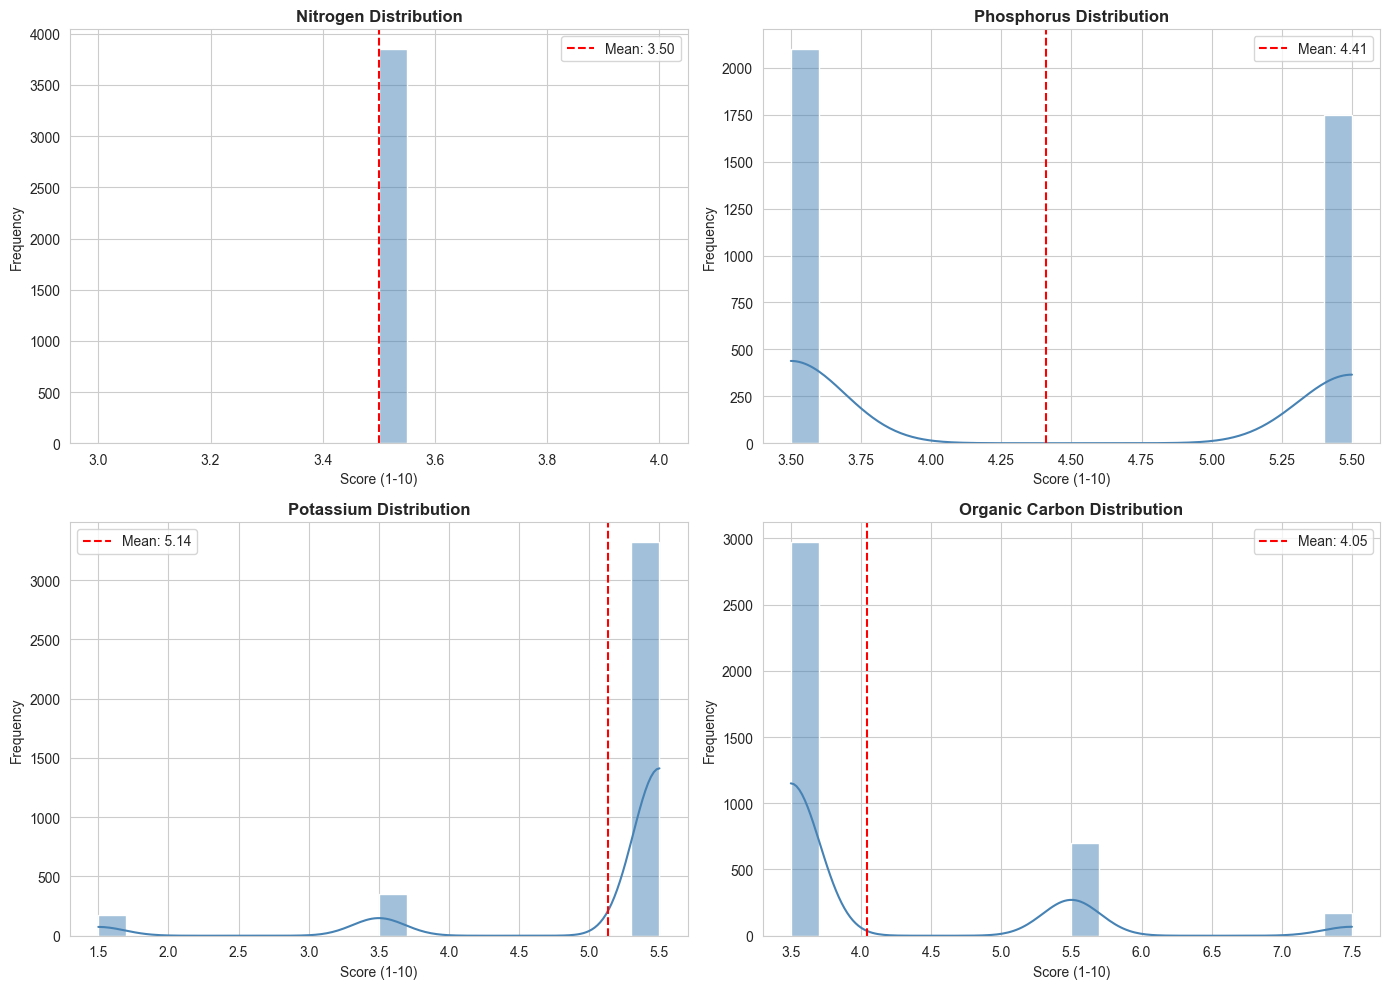

In [5]:
# Key nutrients to analyze
nutrients = ['Nitrogen_scale(1-10)', 'Phosphorus_scale(1-10)', 'Potassium_scale(1-10)', 
             'Organic Carbon_scale(1-10)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(nutrients):
    sns.histplot(df[col], kde=True, bins=20, color='steelblue', ax=axes[idx])
    axes[idx].set_title(f'{col.replace("_scale(1-10)", "")} Distribution', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Score (1-10)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', 
                      label=f'Mean: {df[col].mean():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('03_nutrient_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

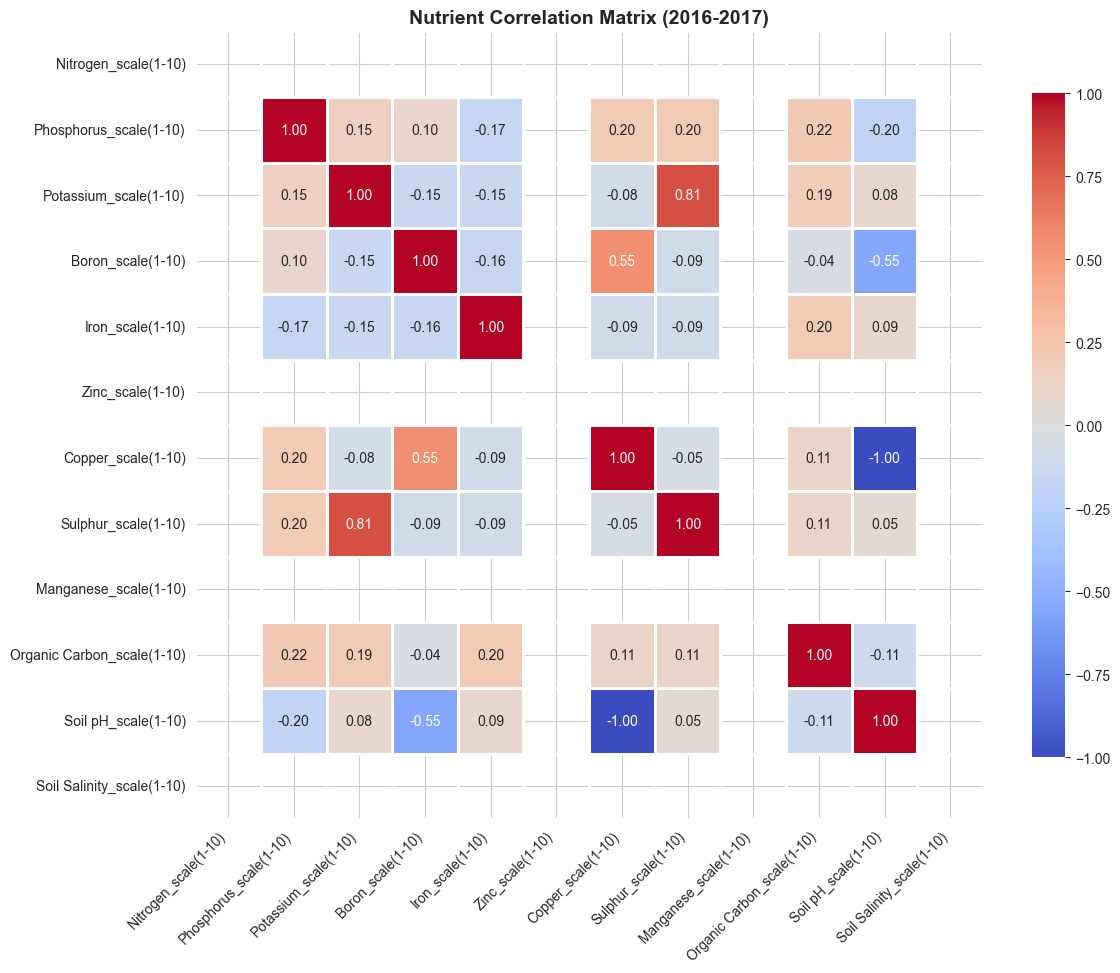


Strongest Positive Correlations:
Potassium_scale(1-10)   Sulphur_scale(1-10)           0.810441
Sulphur_scale(1-10)     Potassium_scale(1-10)         0.810441
Copper_scale(1-10)      Boron_scale(1-10)             0.549170
Boron_scale(1-10)       Copper_scale(1-10)            0.549170
Phosphorus_scale(1-10)  Organic Carbon_scale(1-10)    0.216025
dtype: float64


In [6]:
# Get all 2016-2017 score columns
score_cols = [col for col in df.columns if '_scale(1-10)' in col and '2025' not in col]

# Calculate correlation
correlation = df[score_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Nutrient Correlation Matrix (2016-2017)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print strongest correlations
print("\nStrongest Positive Correlations:")
corr_pairs = correlation.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.sort_values(ascending=False).head(5))

## 6. Nutrient vs Soil Health (Boxplots)

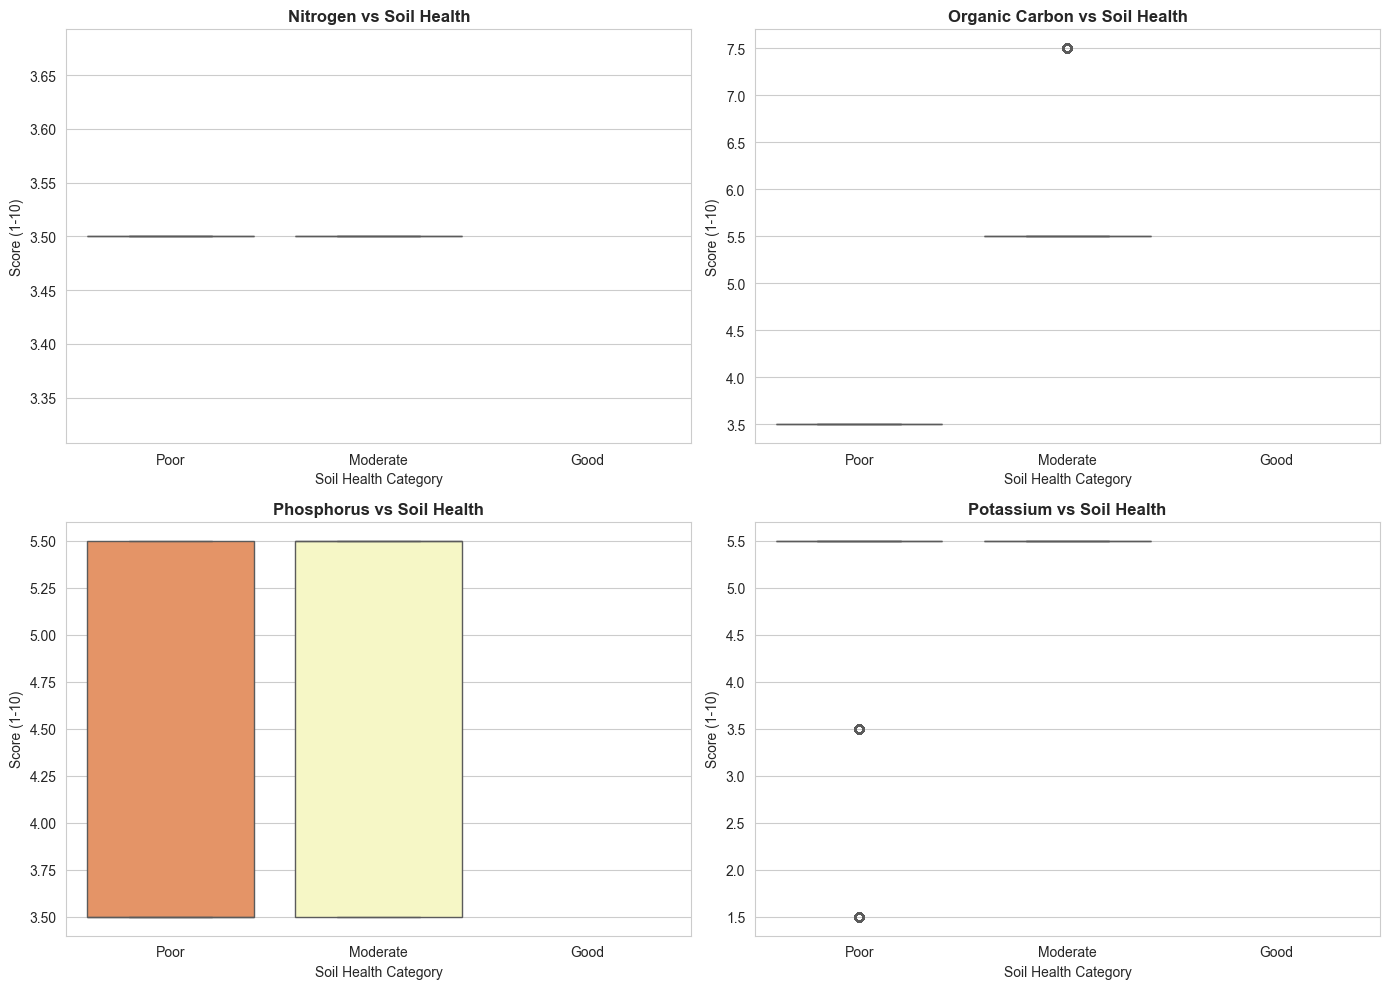

In [7]:
# Key nutrients affecting soil health
key_nutrients = ['Nitrogen_scale(1-10)', 'Organic Carbon_scale(1-10)', 
                 'Phosphorus_scale(1-10)', 'Potassium_scale(1-10)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, nutrient in enumerate(key_nutrients):
    sns.boxplot(x='Soil_Health', y=nutrient, data=df, 
                order=['Poor', 'Moderate', 'Good'],
                palette='RdYlGn', ax=axes[idx])
    axes[idx].set_title(f'{nutrient.replace("_scale(1-10)", "")} vs Soil Health', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Soil Health Category')
    axes[idx].set_ylabel('Score (1-10)')

plt.tight_layout()
plt.savefig('05_nutrients_vs_soil_health.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Temporal Comparison (2016-2017 vs 2025)

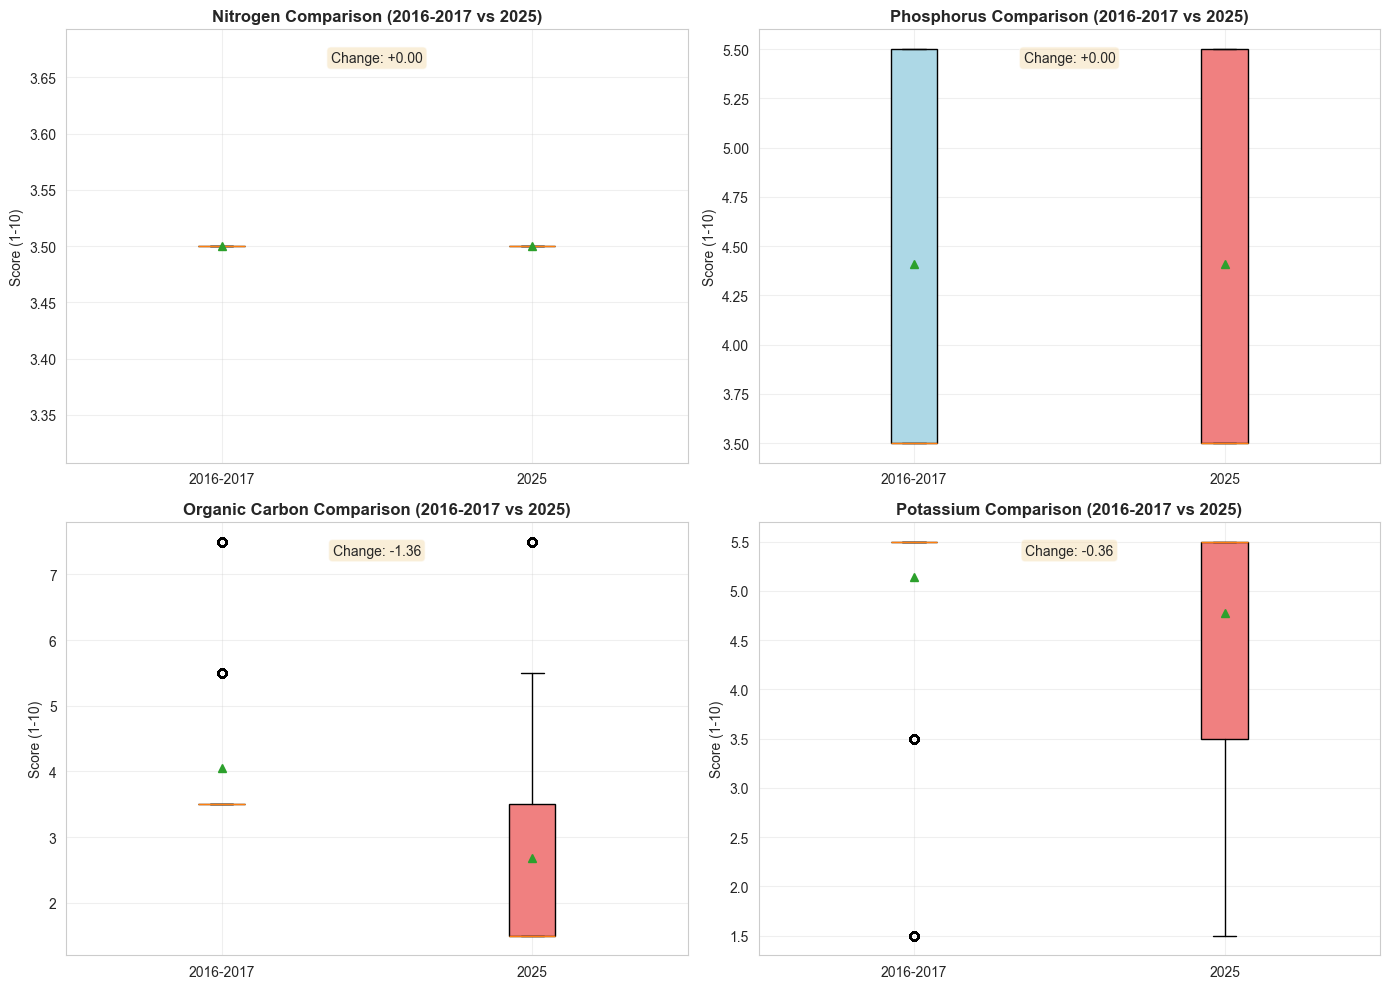

In [8]:
# Compare key nutrients over time
nutrients_to_compare = [
    ('Nitrogen_scale(1-10)', 'Nitrogen_2025_scale(1-10)', 'Nitrogen'),
    ('Phosphorus_scale(1-10)', 'Phosphorus_2025_scale(1-10)', 'Phosphorus'),
    ('Organic Carbon_scale(1-10)', 'Organic Carbon_2025_scale(1-10)', 'Organic Carbon'),
    ('Potassium_scale(1-10)', 'Potassium_2025_scale(1-10)', 'Potassium')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col_2016, col_2025, name) in enumerate(nutrients_to_compare):
    data_to_plot = [df[col_2016].dropna(), df[col_2025].dropna()]
    
    bp = axes[idx].boxplot(data_to_plot, labels=['2016-2017', '2025'], 
                           patch_artist=True, showmeans=True)
    
    # Color boxes
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[idx].set_title(f'{name} Comparison (2016-2017 vs 2025)', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score (1-10)')
    axes[idx].grid(True, alpha=0.3)
    
    # Add mean values as text
    mean_2016 = df[col_2016].mean()
    mean_2025 = df[col_2025].mean()
    change = mean_2025 - mean_2016
    axes[idx].text(0.5, 0.95, f'Change: {change:+.2f}', 
                   transform=axes[idx].transAxes, 
                   ha='center', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('06_temporal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. District-Level Analysis

<Figure size 1400x600 with 0 Axes>

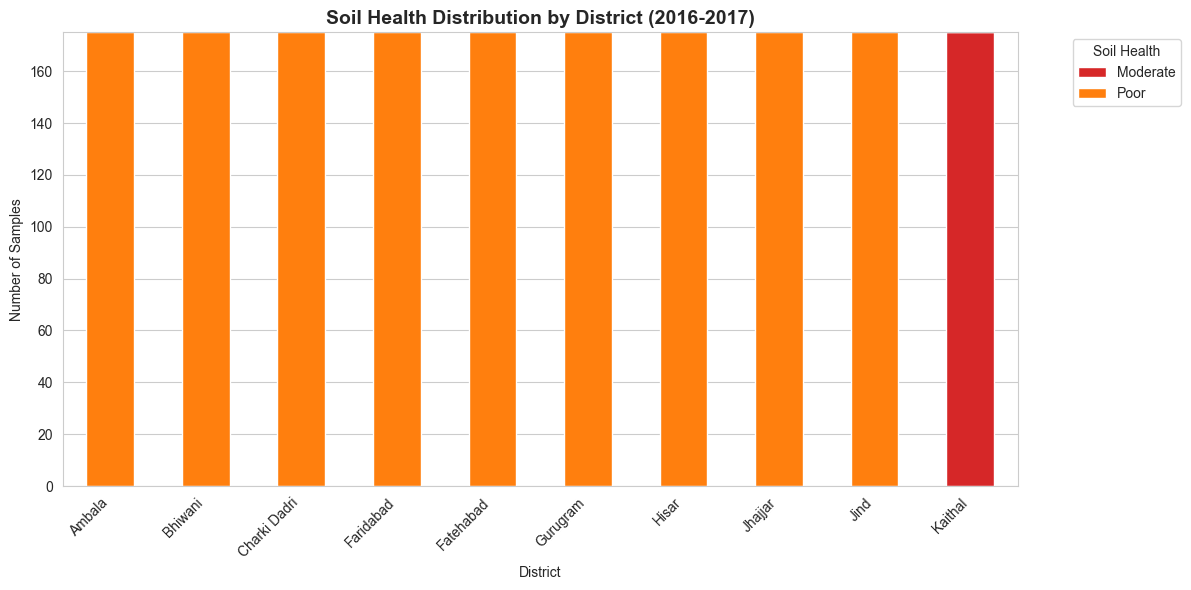


Top 5 Districts with Highest Poor Soil Percentage:
District
Ambala          100.0
Bhiwani         100.0
Charki Dadri    100.0
Faridabad       100.0
Fatehabad       100.0
dtype: float64


In [9]:
# District-wise soil health distribution
district_health = pd.crosstab(df['District'], df['Soil_Health'])

# Plot top 10 districts by sample count
top_districts = df['District'].value_counts().head(10).index
district_health_top = district_health.loc[top_districts]

plt.figure(figsize=(14, 6))
district_health_top.plot(kind='bar', stacked=True, 
                         color=['#d62728', '#ff7f0e', '#2ca02c'])
plt.title('Soil Health Distribution by District (2016-2017)', 
          fontsize=14, fontweight='bold')
plt.xlabel('District')
plt.ylabel('Number of Samples')
plt.legend(title='Soil Health', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('07_district_soil_health.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate percentage of Poor soil by district
district_poor_pct = (district_health['Poor'] / district_health.sum(axis=1) * 100).sort_values(ascending=False)
print("\nTop 5 Districts with Highest Poor Soil Percentage:")
print(district_poor_pct.head())

## 9. Average Nutrient Scores by District

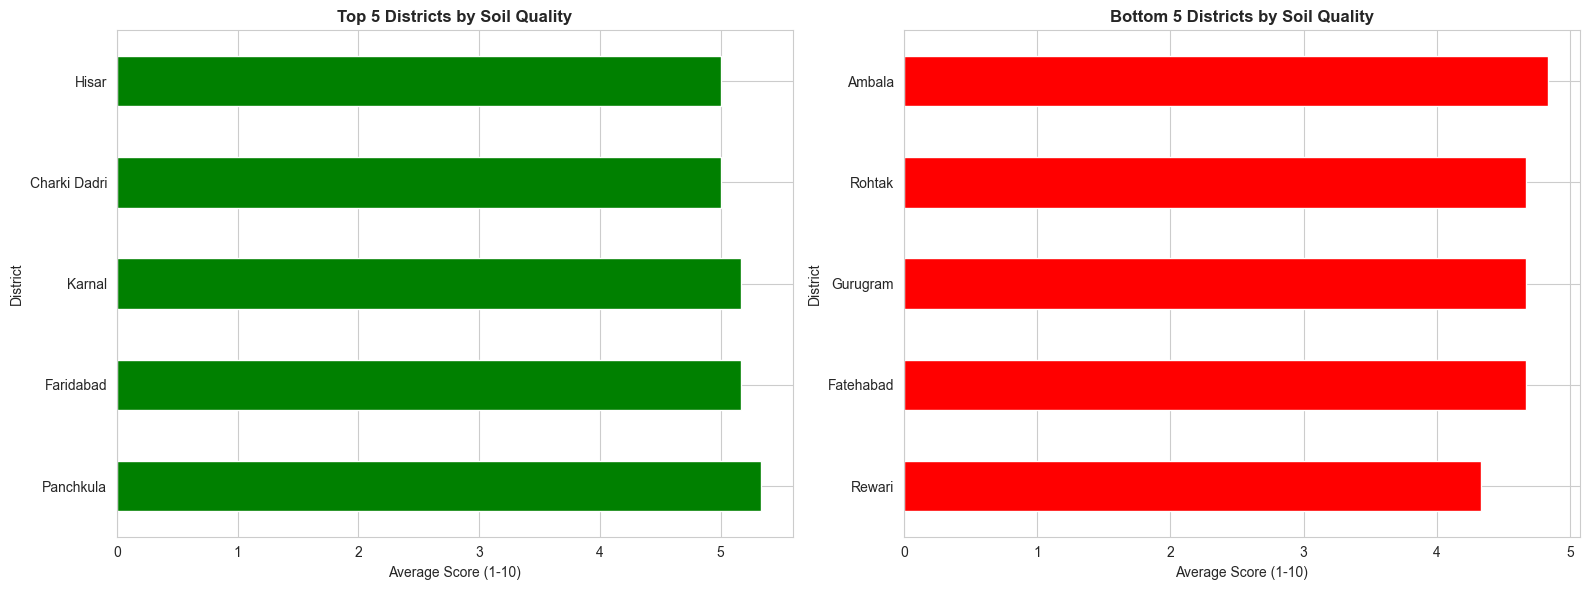


Top 5 Districts:
              Overall_Avg
District                 
Panchkula        5.333333
Faridabad        5.166667
Karnal           5.166667
Charki Dadri     5.000000
Hisar            5.000000

Bottom 5 Districts:
           Overall_Avg
District              
Rewari        4.333333
Fatehabad     4.666667
Gurugram      4.666667
Rohtak        4.666667
Ambala        4.833333


In [10]:
# Calculate average scores by district
score_cols_2016 = [col for col in df.columns if '_scale(1-10)' in col and '2025' not in col]
district_avg = df.groupby('District')[score_cols_2016].mean()
district_avg['Overall_Avg'] = district_avg.mean(axis=1)

# Plot top and bottom 5 districts
top_5 = district_avg.nlargest(5, 'Overall_Avg')
bottom_5 = district_avg.nsmallest(5, 'Overall_Avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 5 districts
top_5['Overall_Avg'].plot(kind='barh', color='green', ax=axes[0])
axes[0].set_title('Top 5 Districts by Soil Quality', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Score (1-10)')
axes[0].set_ylabel('District')

# Bottom 5 districts
bottom_5['Overall_Avg'].plot(kind='barh', color='red', ax=axes[1])
axes[1].set_title('Bottom 5 Districts by Soil Quality', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Score (1-10)')
axes[1].set_ylabel('District')

plt.tight_layout()
plt.savefig('08_district_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Districts:")
print(top_5[['Overall_Avg']])
print("\nBottom 5 Districts:")
print(bottom_5[['Overall_Avg']])

## 9.1. Scatter Plot: Nitrogen vs Organic Carbon

This scatter plot reveals the relationship between Nitrogen and Organic Carbon, colored by soil health category.

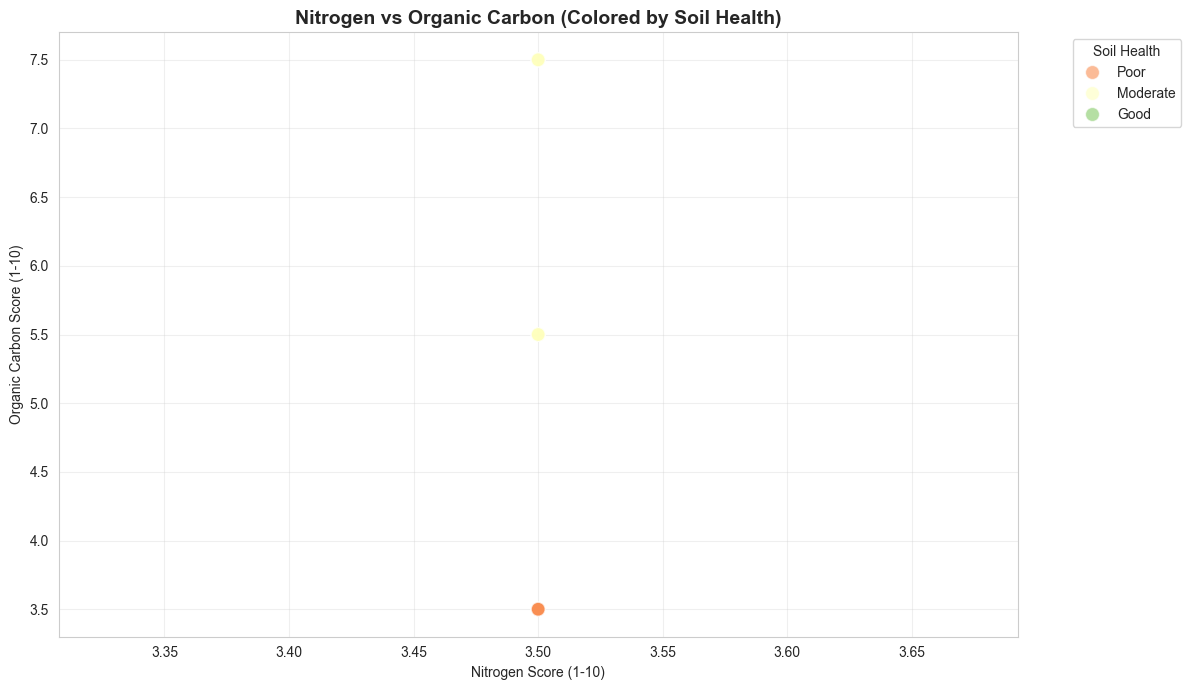


Correlation between Nitrogen and Organic Carbon:
Correlation coefficient: nan


In [11]:
# Nitrogen vs Organic Carbon colored by Soil Health
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Nitrogen_scale(1-10)', 
    y='Organic Carbon_scale(1-10)',
    hue='Soil_Health',
    hue_order=['Poor', 'Moderate', 'Good'],
    palette='RdYlGn',
    data=df,
    s=100,
    alpha=0.6
)
plt.title('Nitrogen vs Organic Carbon (Colored by Soil Health)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Nitrogen Score (1-10)')
plt.ylabel('Organic Carbon Score (1-10)')
plt.legend(title='Soil Health', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('09_nitrogen_vs_organic_carbon.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation between Nitrogen and Organic Carbon:")
print(f"Correlation coefficient: {df['Nitrogen_scale(1-10)'].corr(df['Organic Carbon_scale(1-10)']):.3f}")

## 10. Summary Statistics

In [12]:
# Summary statistics for key nutrients
print("\n" + "="*80)
print("SUMMARY STATISTICS - 2016-2017 DATA")
print("="*80)
print(df[score_cols_2016].describe())

score_cols_2025 = [col for col in df.columns if '2025_scale(1-10)' in col]
print("\n" + "="*80)
print("SUMMARY STATISTICS - 2025 DATA")
print("="*80)
print(df[score_cols_2025].describe())

# Calculate overall changes
print("\n" + "="*80)
print("OVERALL CHANGES (2025 vs 2016-2017)")
print("="*80)
for col_2016 in score_cols_2016:
    mineral = col_2016.replace('_scale(1-10)', '')
    col_2025 = f"{mineral}_2025_scale(1-10)"
    if col_2025 in df.columns:
        avg_2016 = df[col_2016].mean()
        avg_2025 = df[col_2025].mean()
        change = avg_2025 - avg_2016
        change_pct = (change / avg_2016 * 100) if avg_2016 != 0 else 0
        status = "↑" if change > 0 else "↓" if change < 0 else "="
        print(f"{mineral:20s}: {avg_2016:5.2f} → {avg_2025:5.2f} ({change:+5.2f}, {change_pct:+5.1f}%) {status}")


SUMMARY STATISTICS - 2016-2017 DATA
       Nitrogen_scale(1-10)  Phosphorus_scale(1-10)  Potassium_scale(1-10)  \
count                3850.0             3850.000000            3850.000000   
mean                    3.5                4.409091               5.136364   
std                     0.0                0.995989               0.979248   
min                     3.5                3.500000               1.500000   
25%                     3.5                3.500000               5.500000   
50%                     3.5                3.500000               5.500000   
75%                     3.5                5.500000               5.500000   
max                     3.5                5.500000               5.500000   

       Boron_scale(1-10)  Iron_scale(1-10)  Zinc_scale(1-10)  \
count        3850.000000       3850.000000            3850.0   
mean            5.227273          5.227273               5.5   
std             0.686438          0.686438               0.0   
min 

## 10.1. Strip Plot: Organic Carbon vs Soil Health

This visualization shows how Organic Carbon scores are distributed across different soil health categories.

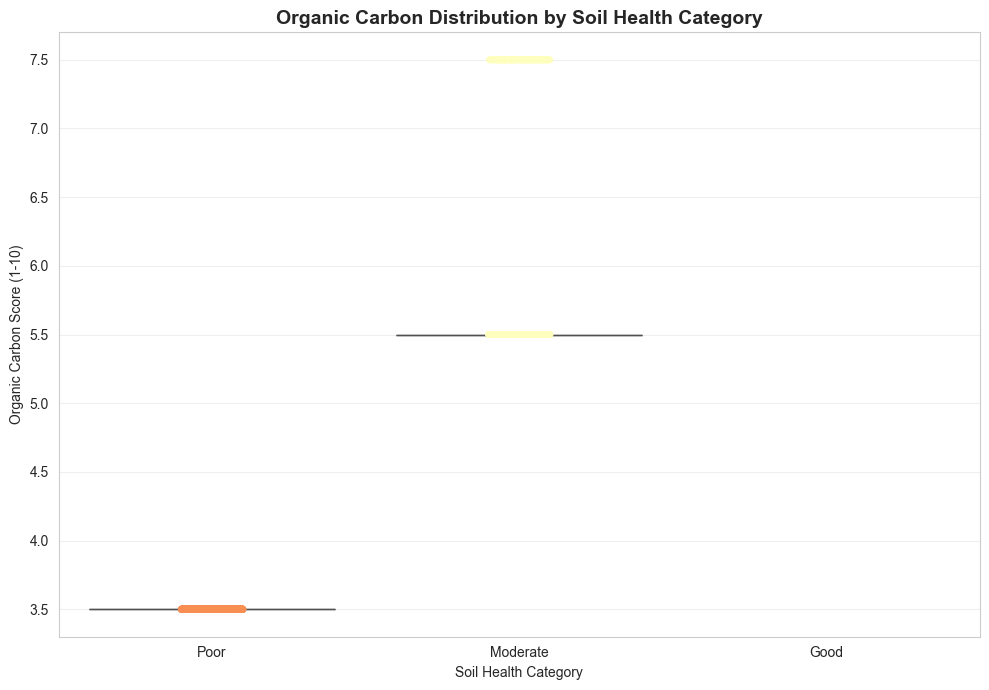


Organic Carbon Statistics by Soil Health:
              count  mean       std  min  25%  50%  75%  max
Soil_Health                                                 
Moderate      875.0   5.9  0.800458  5.5  5.5  5.5  5.5  7.5
Poor         2975.0   3.5  0.000000  3.5  3.5  3.5  3.5  3.5


In [13]:
# Organic Carbon distribution across Soil Health categories
plt.figure(figsize=(10, 7))
sns.stripplot(
    x='Soil_Health', 
    y='Organic Carbon_scale(1-10)',
    order=['Poor', 'Moderate', 'Good'],
    palette='RdYlGn',
    data=df,
    size=5,
    alpha=0.6,
    jitter=True
)
# Add boxplot overlay for better visualization
sns.boxplot(
    x='Soil_Health', 
    y='Organic Carbon_scale(1-10)',
    order=['Poor', 'Moderate', 'Good'],
    data=df,
    showcaps=False,
    boxprops={'facecolor':'None'},
    showfliers=False,
    whiskerprops={'linewidth':0}
)
plt.title('Organic Carbon Distribution by Soil Health Category', 
          fontsize=14, fontweight='bold')
plt.xlabel('Soil Health Category')
plt.ylabel('Organic Carbon Score (1-10)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('10_organic_carbon_vs_soil_health.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\nOrganic Carbon Statistics by Soil Health:")
print(df.groupby('Soil_Health')['Organic Carbon_scale(1-10)'].describe())

## 11. Scatter Plot: 2016-2017 vs 2025 Comparison (CRITICAL!)

This is the most important visualization showing temporal degradation. Points below the diagonal indicate degradation.

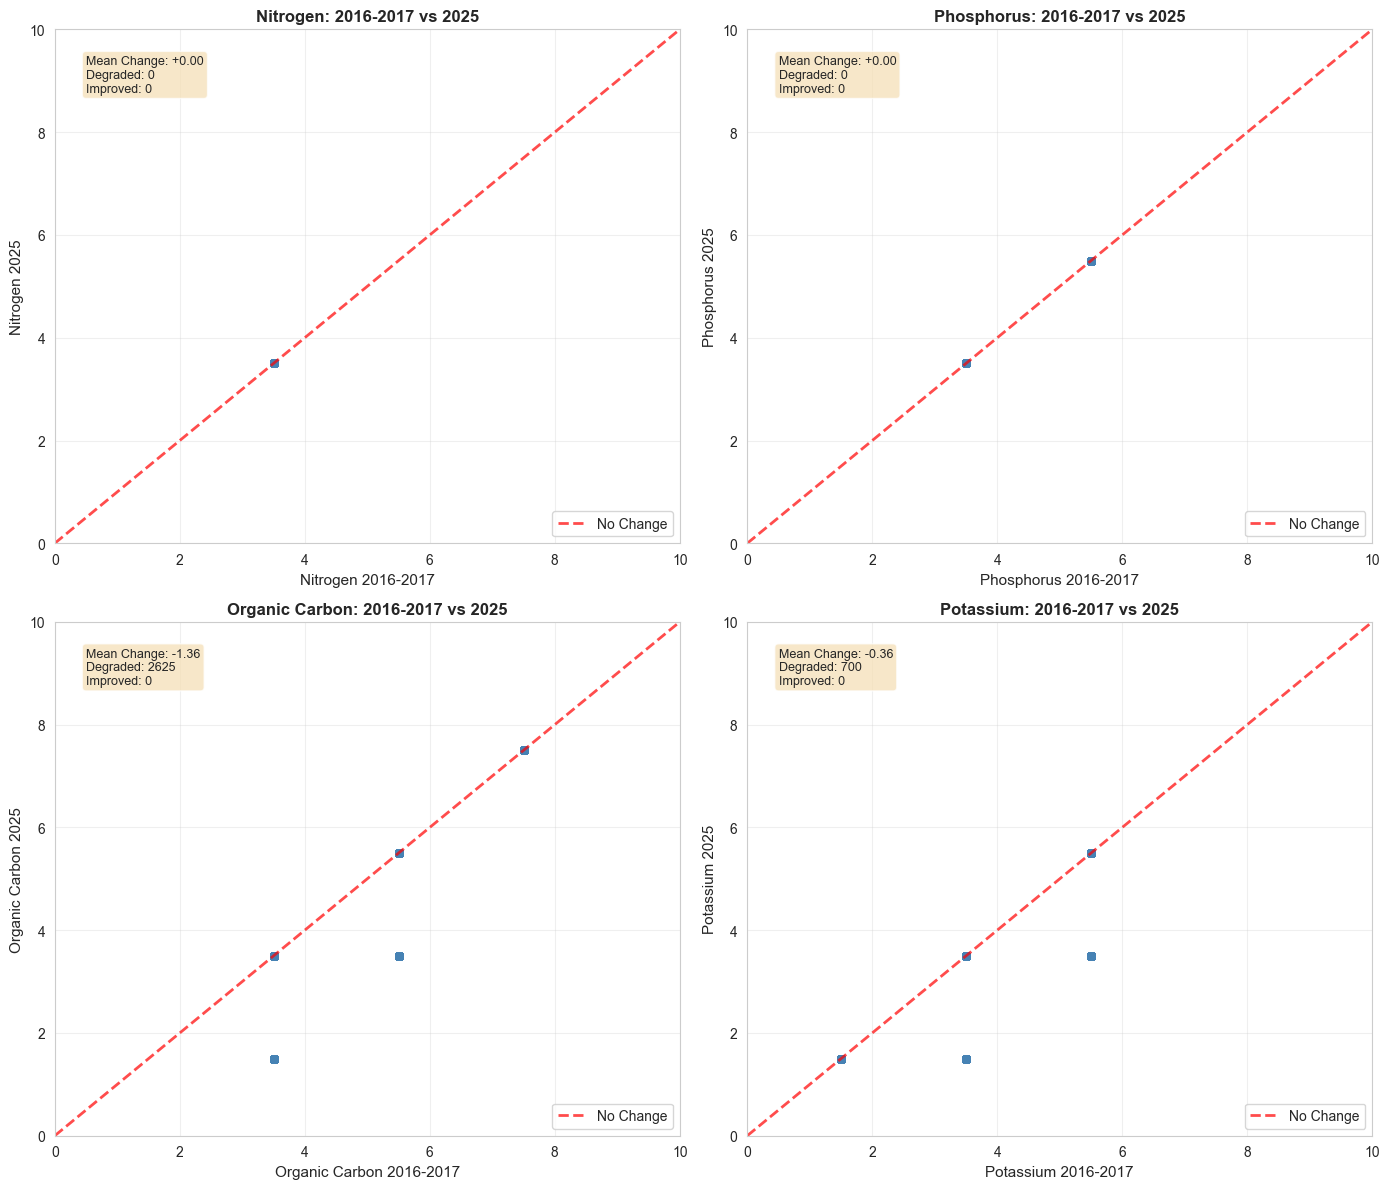


TEMPORAL COMPARISON INSIGHTS

Nitrogen:
  Degraded: 0 samples (0.0%)
  Improved: 0 samples (0.0%)
  Unchanged: 3850 samples (100.0%)

Phosphorus:
  Degraded: 0 samples (0.0%)
  Improved: 0 samples (0.0%)
  Unchanged: 3850 samples (100.0%)

Organic Carbon:
  Degraded: 2625 samples (68.2%)
  Improved: 0 samples (0.0%)
  Unchanged: 1225 samples (31.8%)

Potassium:
  Degraded: 700 samples (18.2%)
  Improved: 0 samples (0.0%)
  Unchanged: 3150 samples (81.8%)


In [14]:
# Compare key nutrients over time with scatter plots
nutrients_to_compare = [
    ('Nitrogen_scale(1-10)', 'Nitrogen_2025_scale(1-10)', 'Nitrogen'),
    ('Phosphorus_scale(1-10)', 'Phosphorus_2025_scale(1-10)', 'Phosphorus'),
    ('Organic Carbon_scale(1-10)', 'Organic Carbon_2025_scale(1-10)', 'Organic Carbon'),
    ('Potassium_scale(1-10)', 'Potassium_2025_scale(1-10)', 'Potassium')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (col_2016, col_2025, name) in enumerate(nutrients_to_compare):
    # Scatter plot
    axes[idx].scatter(df[col_2016], df[col_2025], alpha=0.5, s=30, c='steelblue')
    
    # Add diagonal reference line (no change)
    axes[idx].plot([0, 10], [0, 10], 'r--', linewidth=2, label='No Change', alpha=0.7)
    
    # Add labels and title
    axes[idx].set_xlabel(f'{name} 2016-2017', fontsize=11)
    axes[idx].set_ylabel(f'{name} 2025', fontsize=11)
    axes[idx].set_title(f'{name}: 2016-2017 vs 2025', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 10)
    axes[idx].set_ylim(0, 10)
    
    # Add statistics text
    mean_2016 = df[col_2016].mean()
    mean_2025 = df[col_2025].mean()
    change = mean_2025 - mean_2016
    
    # Count points below diagonal (degradation)
    degraded = ((df[col_2025] < df[col_2016])).sum()
    improved = ((df[col_2025] > df[col_2016])).sum()
    
    stats_text = f'Mean Change: {change:+.2f}\nDegraded: {degraded}\nImproved: {improved}'
    axes[idx].text(0.05, 0.95, stats_text, transform=axes[idx].transAxes,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='wheat', alpha=0.7), fontsize=9)

plt.tight_layout()
plt.savefig('11_temporal_scatter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("TEMPORAL COMPARISON INSIGHTS")
print("="*80)
for col_2016, col_2025, name in nutrients_to_compare:
    degraded = ((df[col_2025] < df[col_2016])).sum()
    improved = ((df[col_2025] > df[col_2016])).sum()
    unchanged = ((df[col_2025] == df[col_2016])).sum()
    print(f"\n{name}:")
    print(f"  Degraded: {degraded} samples ({degraded/len(df)*100:.1f}%)")
    print(f"  Improved: {improved} samples ({improved/len(df)*100:.1f}%)")
    print(f"  Unchanged: {unchanged} samples ({unchanged/len(df)*100:.1f}%)")

## 12. Pairplot: Multi-Variable Relationships (Advanced)

This advanced visualization shows relationships between multiple nutrients simultaneously.


Generating pairplot (this may take a moment)...


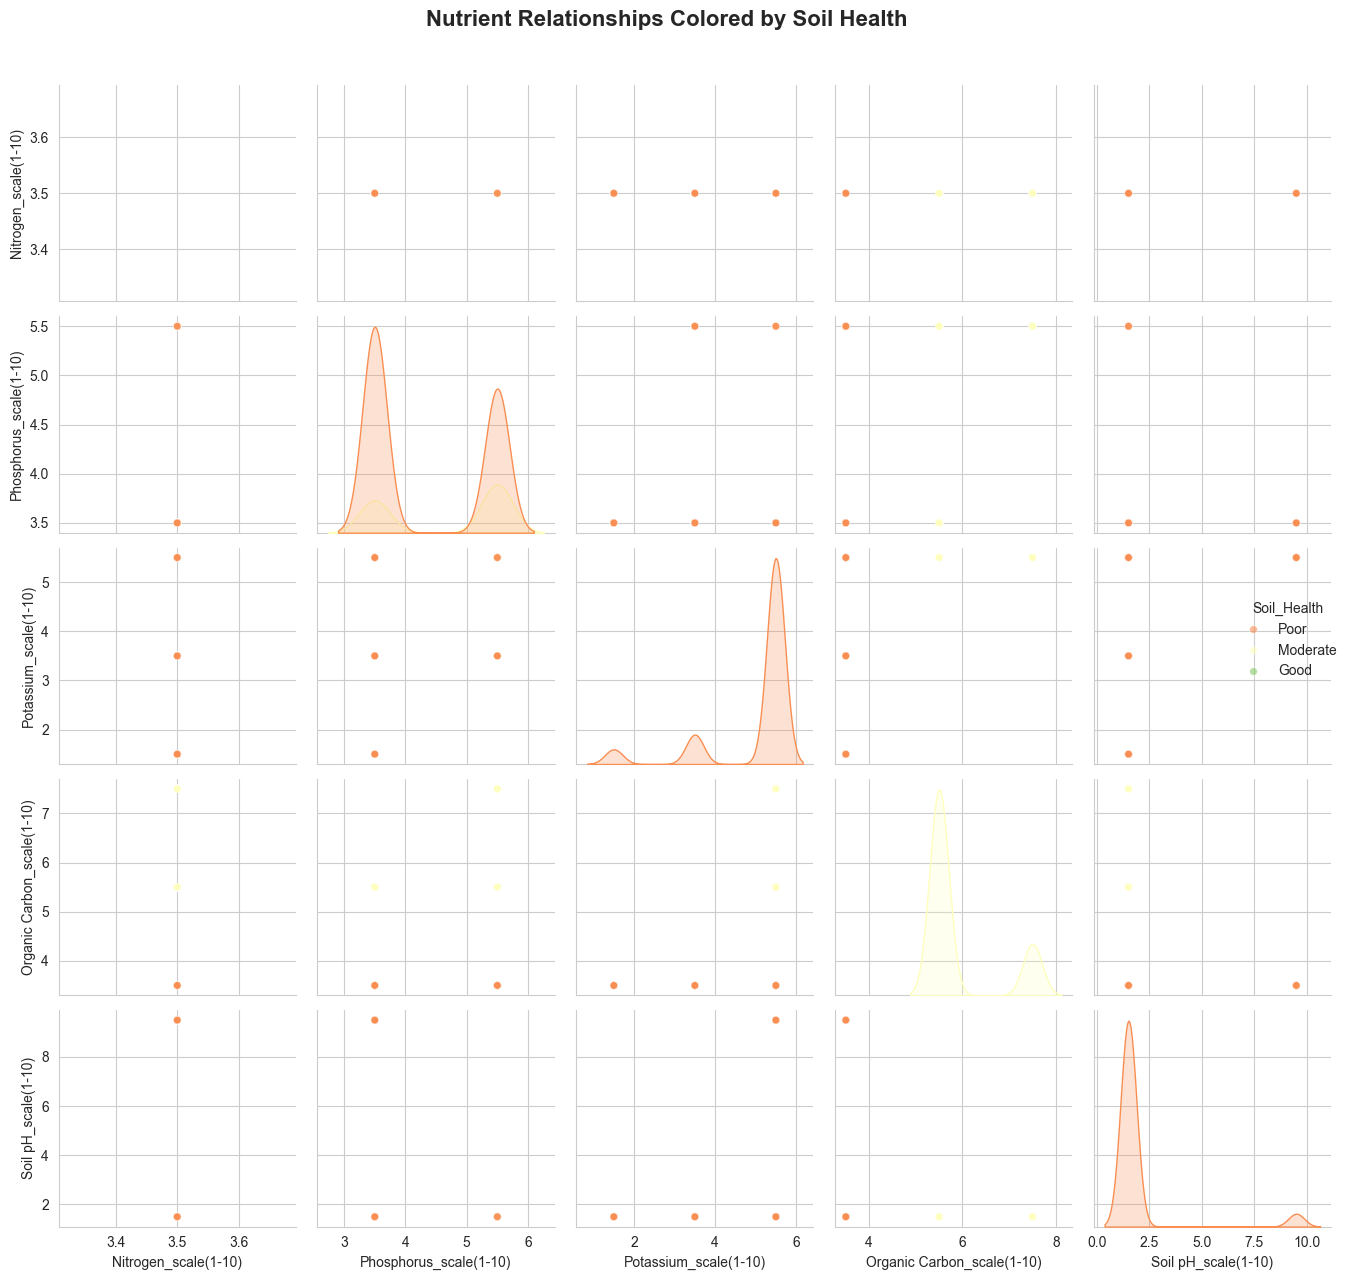


Pairplot generated successfully!
This visualization shows:
- Diagonal: Distribution of each nutrient
- Off-diagonal: Relationships between pairs of nutrients
- Colors: Soil Health categories (Poor/Moderate/Good)


In [15]:
# Select key variables for pairplot
pairplot_cols = [
    'Nitrogen_scale(1-10)',
    'Phosphorus_scale(1-10)',
    'Potassium_scale(1-10)',
    'Organic Carbon_scale(1-10)',
    'Soil pH_scale(1-10)',
    'Soil_Health'
]

# Create pairplot
print("\nGenerating pairplot (this may take a moment)...")
g = sns.pairplot(
    df[pairplot_cols], 
    hue='Soil_Health',
    hue_order=['Poor', 'Moderate', 'Good'],
    palette='RdYlGn',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30},
    height=2.5
)
g.fig.suptitle('Nutrient Relationships Colored by Soil Health', 
               y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('12_pairplot_nutrients.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPairplot generated successfully!")
print("This visualization shows:")
print("- Diagonal: Distribution of each nutrient")
print("- Off-diagonal: Relationships between pairs of nutrients")
print("- Colors: Soil Health categories (Poor/Moderate/Good)")

## Key Findings

### 1. Overall Soil Health Degradation
- Poor soil increased from 77.27% to 81.82%
- 175 samples degraded from Moderate to Poor
- No samples improved

### 2. Critical Nutrient Declines
- Manganese: -36.4%
- Sulphur: -35.3%
- Organic Carbon: -33.7%
- Boron: -33.0%
- Iron: -33.0%

### 3. Stable Parameters
- Nitrogen: No change
- Soil pH: Stable
- Soil Salinity: Stable

### 4. District Insights
- Panchkula: Best performing district
- All districts show declining trends
- Micronutrient depletion is widespread

## Summary of Scatter Plot Insights

### Key Findings:

1. **Nitrogen vs Organic Carbon**: Shows the relationship between primary nutrient and soil foundation
2. **Organic Carbon vs Soil Health**: Validates OC as critical parameter with clear separation between categories
3. **Temporal Comparison (2016 vs 2025)**: 
   - Points below diagonal = degradation
   - Points above diagonal = improvement
   - Most points below diagonal = systematic degradation
4. **Pairplot Analysis**: Reveals complex relationships between multiple nutrients and clustering patterns

---

**All visualizations complete!** 12 PNG files have been generated for your presentation.